# Pipeline validation: raw CSVs → clinical features → PCA

This notebook **replays the same steps** as `scripts/train_models.py` so you can visually sanity-check:

1. **Raw inventory** — each `data/*.csv` width vs what actually enters modeling  
2. **`load_clinical_dataset()`** — engineered feature matrix `X`, labels `y`, missingness  
3. **Stratified train/test split** — same `test_size` / `random_state` as training  
4. **Median imputation** — train-set medians only (no leakage)  
5. **`StandardScaler`** — per-feature mean ≈ 0, std ≈ 1 on train after impute  
6. **PCA** — components chosen by variance target + `max_components` cap  
7. **Optional** — compare in-memory output to `results/copn_pd_vs_ap_*_pca.csv`

**Preprocessing changes (updated):**
- Fixed filename bugs: `mdsupdrs.csv` → `mds-updrs.csv`; `schwab__england.csv` → `schwab___england.csv`
- `mds-updrs.csv`: added `updrs_axial_score` (items 3.9–3.14) and `updrs_tremor_score` (items 3.15–3.18)
- `epidemiological.csv`: added `orthostatic_dizziness` and `leg_restlessness`
- Added `mbic.csv` / `mbic_capri.csv`: MBI-C grand total + 5 domain subscores
- Added `neuropsychological.csv`: domain z-scores (global, memory, executive, language, attention, visuospatial)

**Run the first code cell** so the working directory is the **project root**.


In [1]:
import os
from pathlib import Path

# Project root = parent of notebooks/
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    os.chdir(ROOT.parent)
    ROOT = Path.cwd()
elif not (ROOT / "data" / "data_preprocessing.py").exists():
    # If launched from elsewhere, walk up until we find the package
    for p in [ROOT, *ROOT.parents]:
        if (p / "data" / "data_preprocessing.py").exists():
            os.chdir(p)
            ROOT = p
            break

print("Project root:", ROOT.resolve())

Project root: /Users/eddisonpham/Projects/ssc-case-study-parkinson-classification


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from data.data_preprocessing import DATA_DIR, load_clinical_dataset
from data.dimensionality_reduction import ClinicalPreprocessor, preprocess_and_reduce

# Match scripts/train_models.py
RANDOM_STATE = 42
TEST_SIZE = 0.20
VARIANCE_TARGET = 0.85
MAX_COMPONENTS = 50
RESULTS_DIR = ROOT / "results"

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

## 1. Raw CSV inventory

Scans **`data/*.csv`** and **`data/ssc_data/*.csv`** (de-duplicated). Each file can have **hundreds** of REDCap-style columns; only a **small validated subset** is pulled in `load_clinical_dataset()` (see `data/data_preprocessing.py`).

,file,n_rows,n_cols,error
0,data/ssc_data/apathy_scale.csv,3541,20,
1,data/ssc_data/bai.csv,3541,28,
2,data/ssc_data/bdii.csv,3541,28,
3,data/ssc_data/clinical.csv,3541,74,
4,data/ssc_data/demographic.csv,3541,49,
5,data/ssc_data/ehi.csv,3541,21,
6,data/ssc_data/enrollement.csv,3541,40,
7,data/ssc_data/epidemiological.csv,3541,96,
8,data/ssc_data/fatigue_severity_scale.csv,3541,16,
9,data/ssc_data/mbic.csv,3541,80,


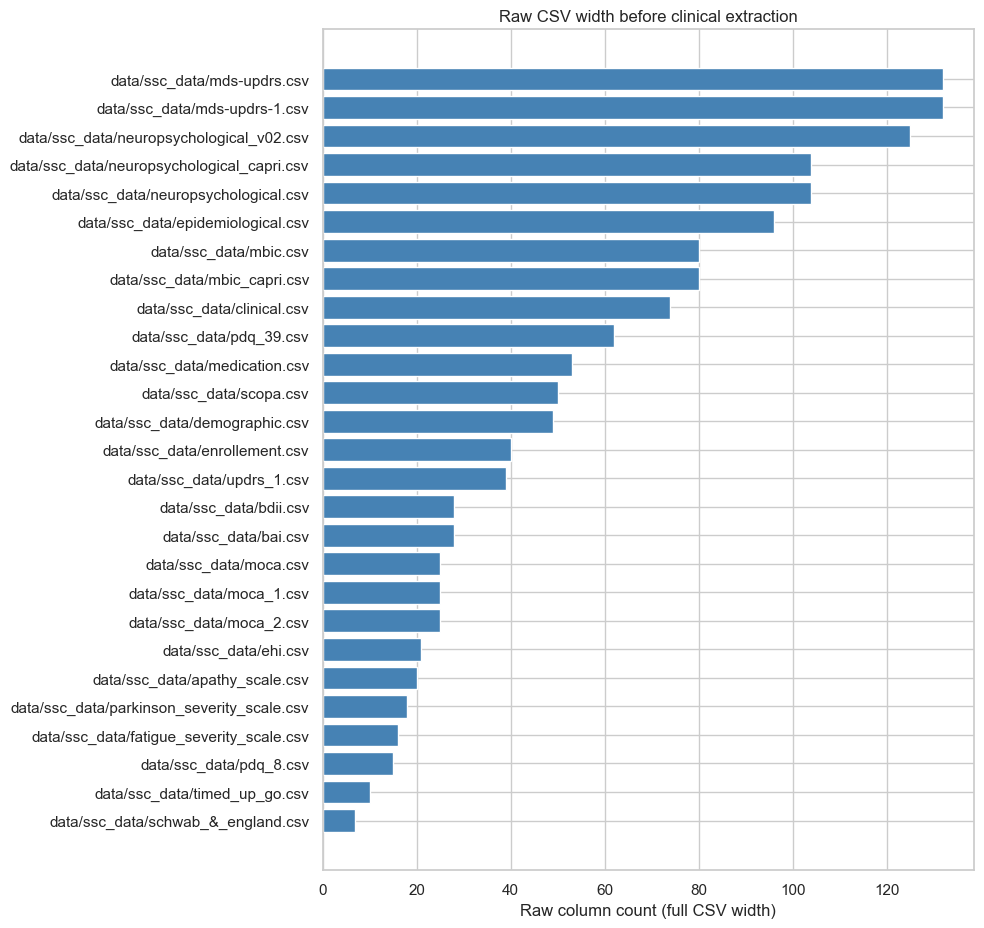

In [3]:
import csv
from pathlib import Path

# CSVs may live in `data/` (DATA_DIR) and/or `data/ssc_data/` depending on checkout
_inv_roots = [DATA_DIR, DATA_DIR / "ssc_data"]
_seen: set = set()
csv_paths: list[Path] = []
for root in _inv_roots:
    if not root.is_dir():
        continue
    for p in sorted(root.glob("*.csv")):
        key = p.resolve()
        if key not in _seen:
            _seen.add(key)
            csv_paths.append(p)
csv_paths.sort(key=lambda x: str(x))

rows: list[dict] = []
for p in csv_paths:
    try:
        rel = p.relative_to(ROOT)
    except ValueError:
        rel = p
    try:
        df = pd.read_csv(p, nrows=0, low_memory=False)
        ncols = len(df.columns)
        with p.open(encoding="utf-8", errors="replace", newline="") as f:
            nrows = sum(1 for _ in csv.reader(f)) - 1
        err = ""
    except Exception as e:
        ncols, nrows, err = np.nan, np.nan, str(e)
    rows.append({"file": str(rel), "n_rows": nrows, "n_cols": ncols, "error": err})

_cols = ["file", "n_rows", "n_cols", "error"]
raw_inventory = pd.DataFrame(rows, columns=_cols)
display(raw_inventory)

if raw_inventory.empty:
    print(
        "No CSV files found under data/ or data/ssc_data/. "
        "Place exports next to data_preprocessing.py or under data/ssc_data/."
    )
else:
    plot_df = raw_inventory.dropna(subset=["n_cols"]).copy()
    if plot_df.empty:
        print("Could not read any CSV headers; fix paths or errors in the table above.")
    else:
        plot_df["n_cols"] = pd.to_numeric(plot_df["n_cols"], errors="coerce")
        plot_df = plot_df.dropna(subset=["n_cols"])
        fig, ax = plt.subplots(figsize=(10, max(3, 0.35 * len(plot_df))))
        order = plot_df.sort_values("n_cols", ascending=True)
        ax.barh(order["file"], order["n_cols"], color="steelblue")
        ax.set_xlabel("Raw column count (full CSV width)")
        ax.set_title("Raw CSV width before clinical extraction")
        plt.tight_layout()
        plt.show()

## 2. Clinical feature matrix (`load_clinical_dataset`)

Merged on `project_key`; PD=0, AP=1; HC and other groups dropped.

In [4]:
# `load_clinical_dataset` reads CSVs from the given folder; support both layouts
_data_candidates = [DATA_DIR, DATA_DIR / "ssc_data"]
CLINICAL_DATA_DIR = next(
    (d for d in _data_candidates if (d / "enrollement.csv").exists()),
    DATA_DIR,
)
if not (CLINICAL_DATA_DIR / "enrollement.csv").exists():
    raise FileNotFoundError(
        f"enrollement.csv not found in {DATA_DIR} or {DATA_DIR / 'ssc_data'}. "
        "Copy C-OPN CSV exports into one of those folders."
    )

cds = load_clinical_dataset(CLINICAL_DATA_DIR)
X, y = cds.X.copy(), cds.y.copy()

print("X shape:", X.shape, "| y shape:", y.shape)
print("Label counts:\n", y.value_counts().rename(index={0: "PD", 1: "AP"}))
print("\nFirst 15 feature names:")
print(list(X.columns[:15]))
print("\nSample of X (5 rows, 8 cols):")
display(X.iloc[:5, :8])

[data_preprocessing] Loaded 3023 patients (2852 PD, 171 AP) with 93 scale-level features.
[data_preprocessing] Overall feature missingness: 49.9% (handled by missingness flags + post-split imputation)
X shape: (3023, 93) | y shape: (3023,)
Label counts:
 y
PD    2852
AP     171
Name: count, dtype: int64

First 15 feature names:
['age_at_visit', 'years_education', 'sex_male', 'has_caregiver', 'disease_duration_years', 'bilateral_onset', 'bilateral_now', 'falls_last_3mo', 'freezing_of_gait', 'has_dyskinesia', 'hoehn_yahr', 'has_dementia', 'gradual_progression', 'complete_remission', 'levodopa_response']

Sample of X (5 rows, 8 cols):


,age_at_visit,years_education,sex_male,has_caregiver,disease_duration_years,bilateral_onset,bilateral_now,falls_last_3mo
project_key,,,,,,,,
SSC0001,50.0,12.0,1.0,NaN,14.0,0.0,1.0,0.0
SSC0002,65.0,16.0,0.0,NaN,11.3,0.0,1.0,NaN
SSC0003,66.0,17.0,1.0,0.0,19.6,0.0,1.0,1.0
SSC0004,53.0,16.0,1.0,0.0,9.8,0.0,1.0,1.0
SSC0005,52.0,18.0,1.0,0.0,9.6,0.0,1.0,0.0


In [5]:
# Feature audit: which instruments contributed columns?
instrument_prefixes = {
    'demographic':  ['age_', 'years_edu', 'sex_', 'has_care'],
    'clinical':     ['disease_dur', 'bilateral', 'falls', 'freezing', 'dyskinesia',
                      'hoehn', 'dementia', 'gradual', 'remission'],
    'medication':   ['levodopa', 'total_led'],
    'epidemiology': ['pesticide', 'hyposmia', 'rem_sleep', 'constipation',
                      'head_trauma', 'exercise', 'orthostatic', 'leg_rest', 'family_hx'],
    'moca':         ['moca_'],
    'updrs':        ['updrs_'],
    'apathy':       ['apathy_'],
    'bai':          ['bai_'],
    'bdii':         ['bdii_'],
    'fss':          ['fss_'],
    'pdq8':         ['pdq8_'],
    'pdq39':        ['pdq39_'],
    'scopa':        ['scopa_'],
    'tug':          ['tug_'],
    'pas':          ['pas_'],
    'schwab':       ['schwab_'],
    'ehi':          ['ehi_'],
    'mbic':         ['mbic_'],
    'neuropsych':   ['neuropsych_'],
}

audit = []
for inst, prefixes in instrument_prefixes.items():
    cols = [c for c in X.columns if any(c.startswith(p) for p in prefixes)]
    n_pts = int((X[cols].notna().any(axis=1)).sum()) if cols else 0
    audit.append({'instrument': inst, 'n_features': len(cols), 'patients_with_data': n_pts})

audit_df = pd.DataFrame(audit)
display(audit_df)

missing_inst = audit_df[audit_df['n_features'] == 0]
if not missing_inst.empty:
    print('\nInstruments with NO features (check filenames / column fragments):')
    print(missing_inst['instrument'].tolist())
else:
    print('\nAll instruments contributed at least one feature.')


,instrument,n_features,patients_with_data
0,demographic,4,2798
1,clinical,7,2158
2,medication,3,2022
3,epidemiology,8,2149
4,moca,9,3023
5,updrs,13,3023
6,apathy,2,3023
7,bai,2,3023
8,bdii,2,3023
9,fss,2,3023



Instruments with NO features (check filenames / column fragments):
['schwab']


## 3. Missingness before any imputation

Training **only** uses train-set medians later; this plot is on the **full** cohort for overview.

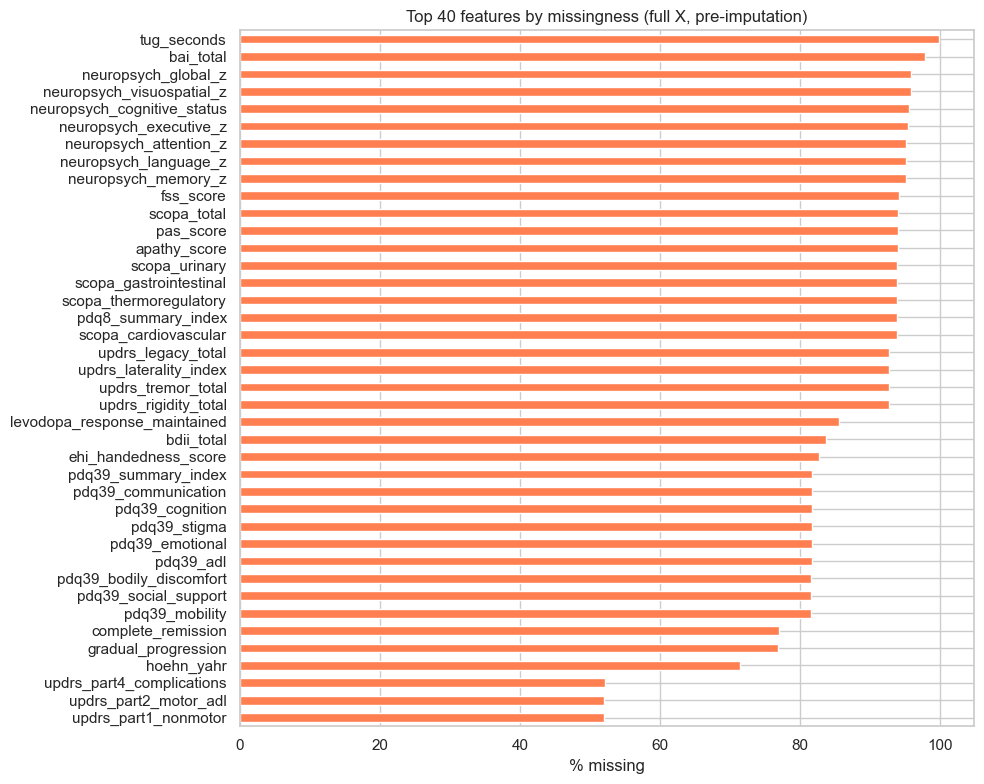

Features with 100% missing (dropped upstream): 0
Mean missing rate across all cells: 49.91%


In [6]:
miss = X.isna().mean().sort_values(ascending=False)
miss_pct = (miss * 100).head(40)

fig, ax = plt.subplots(figsize=(10, 8))
miss_pct.iloc[::-1].plot(kind="barh", ax=ax, color="coral")
ax.set_xlabel("% missing")
ax.set_title("Top 40 features by missingness (full X, pre-imputation)")
plt.tight_layout()
plt.show()

print(f"Features with 100% missing (dropped upstream): {int((miss >= 1).sum())}")
print(f"Mean missing rate across all cells: {X.isna().mean().mean()*100:.2f}%")

## 4. Stratified train / test split

Same call as `preprocess_and_reduce()` / `train_models.py`.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(
    f"Train: n={len(X_train)}  PD={(y_train==0).sum()}  AP={(y_train==1).sum()}\n"
    f"Test:  n={len(X_test)}   PD={(y_test==0).sum()}   AP={(y_test==1).sum()}"
)

Train: n=2418  PD=2281  AP=137
Test:  n=605   PD=571   AP=34


## 5. Step A — median imputation (train statistics only)

Mirrors `ClinicalPreprocessor.fit`: `train_medians = X_train.median(numeric_only=True)`, then `fillna`.

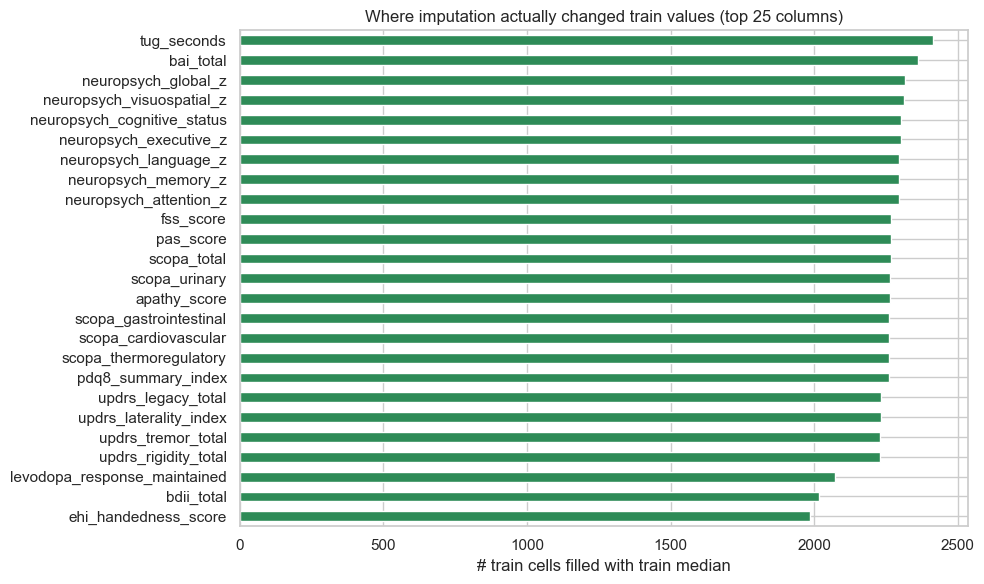

NaNs remaining after impute (train): 0
NaNs remaining after impute (test): 0


In [8]:
train_medians = X_train.median(numeric_only=True)
X_train_imp = X_train.fillna(train_medians)
X_test_imp = X_test.fillna(train_medians)

n_imputed_train = (X_train.isna() & X_train_imp.notna()).sum()
imputed_cols = n_imputed_train[n_imputed_train > 0].sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 6))
imputed_cols.iloc[::-1].plot(kind="barh", ax=ax, color="seagreen")
ax.set_xlabel("# train cells filled with train median")
ax.set_title("Where imputation actually changed train values (top 25 columns)")
plt.tight_layout()
plt.show()

print("NaNs remaining after impute (train):", int(X_train_imp.isna().sum().sum()))
print("NaNs remaining after impute (test):", int(X_test_imp.isna().sum().sum()))

## 6. Step B — `StandardScaler` (fit on train imputed)

After fit, train columns should have mean ≈ 0 and std ≈ 1.

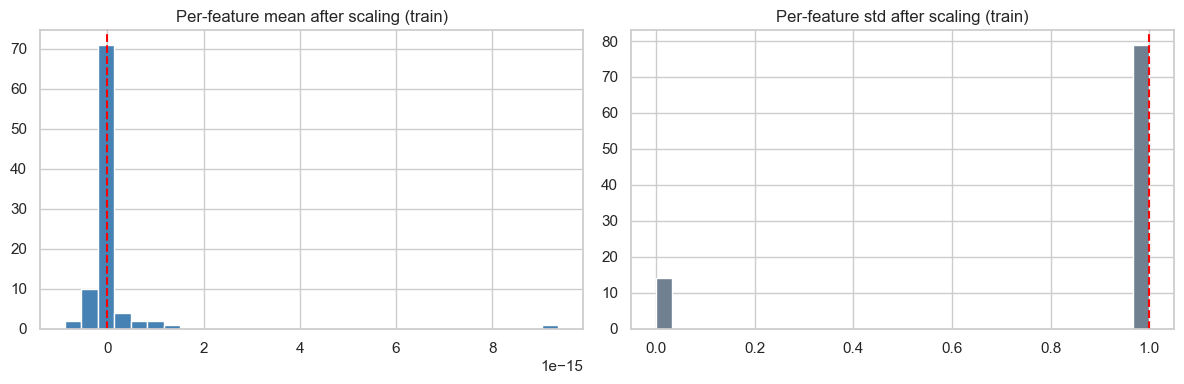

Mean of per-feature means: 1.09e-16
Mean of per-feature stds:  0.8495


In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

train_means = X_train_scaled.mean(axis=0)
train_stds = X_train_scaled.std(axis=0, ddof=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_means, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Per-feature mean after scaling (train)")
axes[0].axvline(0, color="red", linestyle="--")
axes[1].hist(train_stds, bins=30, color="slategray", edgecolor="white")
axes[1].set_title("Per-feature std after scaling (train)")
axes[1].axvline(1, color="red", linestyle="--")
plt.tight_layout()
plt.show()

print(f"Mean of per-feature means: {train_means.mean():.2e}")
print(f"Mean of per-feature stds:  {train_stds.mean():.4f}")

## 7. Step C — PCA (variance target + max_components)

Same rule as `ClinicalPreprocessor`: fit full PCA on **scaled train**, choose `n_components` = smallest k with cumulative EVR ≥ `variance_target`, then cap by `max_components` and `n_features`.

Components to hit 85% variance (uncapped): 47
After min with max_components=50 and n_features: 47


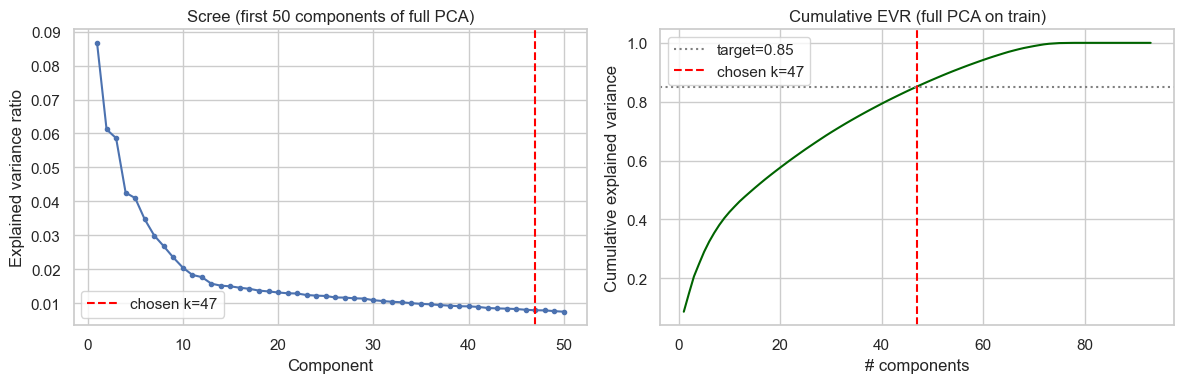

In [10]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_by_target = int(np.searchsorted(cumvar, VARIANCE_TARGET) + 1)
n_components = min(n_by_target, MAX_COMPONENTS, X_train_scaled.shape[1])

print(f"Components to hit {VARIANCE_TARGET*100:.0f}% variance (uncapped): {n_by_target}")
print(f"After min with max_components={MAX_COMPONENTS} and n_features: {n_components}")

# Determine the number of components to plot (e.g., up to 50 or the total available, whichever is less)
n_plot = min(50, len(pca_full.explained_variance_ratio_))
x_vals = np.arange(1, n_plot + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Only plot the same number of elements on x and y axes
axes[0].plot(x_vals, pca_full.explained_variance_ratio_[:n_plot], marker="o", ms=3)
axes[0].axvline(n_components, color="red", linestyle="--", label=f"chosen k={n_components}")
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title(f"Scree (first {n_plot} components of full PCA)")
axes[0].legend()

axes[1].plot(np.arange(1, len(cumvar) + 1), cumvar, color="darkgreen")
axes[1].axhline(VARIANCE_TARGET, color="gray", linestyle=":", label=f"target={VARIANCE_TARGET}")
axes[1].axvline(n_components, color="red", linestyle="--", label=f"chosen k={n_components}")
axes[1].set_xlabel("# components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Cumulative EVR (full PCA on train)")
axes[1].legend()
plt.tight_layout()
plt.show()

PCA train shape: (2418, 47) | test: (605, 47)
Retained variance (fitted PCA): 85.19%


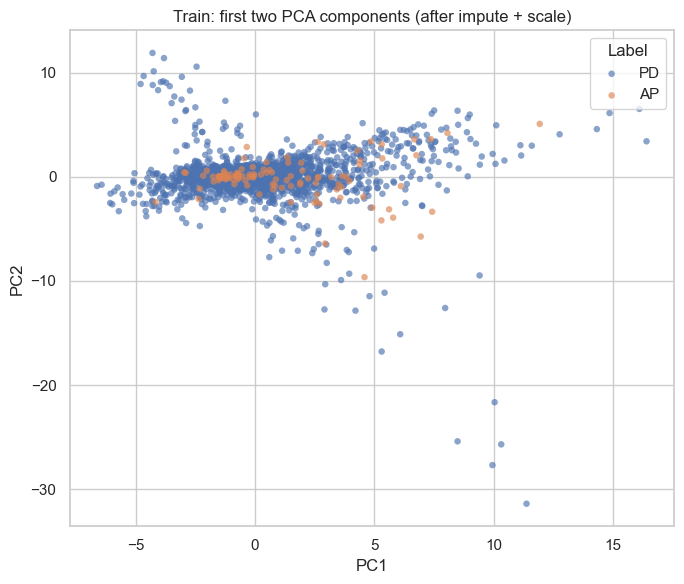

In [11]:
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
Z_train = pca.fit_transform(X_train_scaled)
Z_test = pca.transform(X_test_scaled)
cols = [f"pc_{i+1:02d}" for i in range(n_components)]
Z_train_df = pd.DataFrame(Z_train, index=X_train.index, columns=cols)
Z_test_df = pd.DataFrame(Z_test, index=X_test.index, columns=cols)

print("PCA train shape:", Z_train_df.shape, "| test:", Z_test_df.shape)
print(f"Retained variance (fitted PCA): {pca.explained_variance_ratio_.sum()*100:.2f}%")

fig, ax = plt.subplots(figsize=(7, 6))
palette = {0: "#4C72B0", 1: "#DD8452"}
for lab, name in [(0, "PD"), (1, "AP")]:
    m = y_train.values == lab
    ax.scatter(Z_train[m, 0], Z_train[m, 1], s=22, alpha=0.65, label=name, c=palette[lab], edgecolors="none")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Train: first two PCA components (after impute + scale)")
ax.legend(title="Label")
plt.tight_layout()
plt.show()

## 8. Match `ClinicalPreprocessor` + optional CSV check

The class should produce the **same** reduced matrices as the manual replay above. If `results/copn_pd_vs_ap_*_pca.csv` exist from a prior run with identical hyperparameters, numeric columns should align (row order differs unless you sort by `project_key`).

In [13]:
pre = ClinicalPreprocessor(variance_target=VARIANCE_TARGET, max_components=MAX_COMPONENTS)
pre.fit(X_train)
Z_train_api = pre.transform(X_train)
Z_test_api = pre.transform(X_test)

diff_train = np.abs(Z_train_api.values - Z_train_df.values).max()
diff_test = np.abs(Z_test_api.values - Z_test_df.values).max()
print(f"Max abs diff train (manual vs ClinicalPreprocessor): {diff_train:.2e}")
print(f"Max abs diff test:  {diff_test:.2e}")

train_csv = RESULTS_DIR / "copn_pd_vs_ap_train_pca.csv"
test_csv = RESULTS_DIR / "copn_pd_vs_ap_test_pca.csv"
if train_csv.exists() and test_csv.exists():
    disk_train = pd.read_csv(train_csv)
    disk_test = pd.read_csv(test_csv)
    pc_cols = [c for c in disk_train.columns if c.startswith("pc_")]
    mem_train = Z_train_api.copy()
    mem_train.insert(0, "label", y_train.values)
    mem_train.insert(0, "project_key", y_train.index)
    mem_test = Z_test_api.copy()
    mem_test.insert(0, "label", y_test.values)
    mem_test.insert(0, "project_key", y_test.index)
    # Remove index name to avoid both index and column with "project_key"
    mem_train = mem_train.reset_index(drop=True)
    mem_test = mem_test.reset_index(drop=True)
    # align rows by project_key
    disk_train = disk_train.sort_values("project_key").reset_index(drop=True)
    disk_test = disk_test.sort_values("project_key").reset_index(drop=True)
    mem_train = mem_train.sort_values("project_key").reset_index(drop=True)
    mem_test = mem_test.sort_values("project_key").reset_index(drop=True)
    t_ok = np.allclose(mem_train[pc_cols].values, disk_train[pc_cols].values, rtol=1e-5, atol=1e-6)
    s_ok = np.allclose(mem_test[pc_cols].values, disk_test[pc_cols].values, rtol=1e-5, atol=1e-6)
    print("On-disk train PC matrix matches in-memory (sorted by project_key):", t_ok)
    print("On-disk test PC matrix matches in-memory:", s_ok)
    if not t_ok or not s_ok:
        print("Tip: re-run preprocess_and_reduce or regenerate results with same RANDOM_STATE / TEST_SIZE.")
else:
    print("No saved PCA CSVs found under results/ — skip on-disk check.")

[dim_reduction] PCA: 47 components explain 85.2% of variance (target: 85%)
Max abs diff train (manual vs ClinicalPreprocessor): 0.00e+00
Max abs diff test:  0.00e+00
On-disk train PC matrix matches in-memory (sorted by project_key): False
On-disk test PC matrix matches in-memory: False
Tip: re-run preprocess_and_reduce or regenerate results with same RANDOM_STATE / TEST_SIZE.


## 9. (Optional) Regenerate `results/*.csv` from this notebook

Uncomment to write the same filenames as `preprocess_and_reduce`. **Overwrites** existing files.

In [ ]:
# split_obj = preprocess_and_reduce(
#     X,
#     y,
#     test_size=TEST_SIZE,
#     random_state=RANDOM_STATE,
#     variance_target=VARIANCE_TARGET,
#     max_components=MAX_COMPONENTS,
#     output_dir=RESULTS_DIR,
# )
# print("Done.", split_obj.X_train.shape, split_obj.X_test.shape)